https://www.kaggle.com/datasets/willianoliveiragibin/harvest-time-traits-yield

# Características da época da colheita_Rendimento
principais culturas em terras agrícolas de observação de longo prazo na Planície Inferior de Liaohe.

A Planície Inferior de Liaohe é uma importante área produtora de grãos em Liaoning, e o Observatório Nacional Científico de Campo de Ecossistemas Agrícolas de Shenyang em Liaoning (doravante denominado Estação Shenyang) está localizado no centro da Planície Inferior de Liaohe. Ele está situado na intersecção de duas zonas de amostragem: a Diretriz de Umidade Leste-Oeste e a Diretriz de Calor Norte-Sul do Programa Internacional Geosfera-Biosfera (IGBP) na China. Portanto, os dados de observação de longo prazo de terras agrícolas na Estação Shenyang podem representar bem as características das principais culturas na Planície Inferior de Liaohe. Isso é de grande importância para orientar a produção agrícola na região e também fornece uma referência de dados para a segurança alimentar nacional. Desde 1998, a Estação Shenyang estabeleceu 10 parcelas de amostragem de monitoramento biológico de longo prazo em ecossistemas de terras agrícolas para realizar a observação contínua de indicadores biológicos, como dinâmica de crescimento das culturas, características da colheita e produtividade, bem como elementos ambientais, incluindo solo, água e atmosfera, acumulando assim uma grande quantidade de dados de observação contínua. Este conjunto de dados é derivado dos dados de observação contínua sobre características de colheita e produtividade de culturas de 2005 a 2015 em 10 parcelas de observação de terras agrícolas de longo prazo na Estação Shenyang. Consiste em oito partes: a tabela do sistema de rotação de culturas, a tabela dos principais pesticidas, herbicidas e outros usos, a tabela do sistema de irrigação de terras agrícolas, a tabela de características das plantas na época da colheita do arroz, a tabela de características das plantas na época da colheita do milho, a tabela de características das plantas na época da colheita da soja, a tabela de características da colheita e medição da produtividade, e a tabela de insumos de fertilizantes das parcelas amostrais. A observação de longo prazo da estação foi realizada em estrita conformidade com as especificações de observação da Rede de Pesquisa de Ecossistemas da China (CERN). O controle de qualidade foi implementado em todo o processo, desde a preparação até a implementação da pesquisa, e a classificação e registro dos dados após a pesquisa, a fim de garantir que os dados fossem precisos e confiáveis. Esses dados fornecem informações sobre características da época da colheita e dinâmica de produção das principais culturas em terras agrícolas na Planície Inferior de Liaohe, que podem ser usadas para avaliar flutuações interanuais de produção e fornecer orientação científica e uma base para tomada de decisões para otimizar a estrutura de plantio agrícola regional e alcançar produções altas e estáveis ​​das principais culturas na região, de modo a fornecer uma forte garantia para a segurança alimentar nacional.

# Objetivo da Análise

O principal objetivo da análise é utilizar essas informações sobre as características da época da colheita e a dinâmica de produção das principais culturas para:

Avaliar as flutuações de produção entre diferentes anos.

Fornecer orientação científica e uma base para tomada de decisões para otimizar a estrutura de plantio agrícola regional.

Alcançar produções altas e estáveis das principais culturas na região, o que contribui para a segurança alimentar nacional.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import joblib
df = pd.read_csv('Harvest Time_Traits_Yield new.csv')

In [2]:
df

,序列号 Serial Number,生态站代码 Ecological Station Code,年 Year,样地代码 Plot Code,样地名称 Plot Name,样地类别 Plot Type,农田类型 Farmland Type,复种指数（%）Multiple Cropping Index (%),轮作体系 Crop Rotation System,当年作物 Current Crop
0,1,SYA,2005,SYAZH01ABC_01,"沈阳站水、土壤、生物联合长期观测采样地01 Water, soil and biology ...",综合观测场 Comprehensive observation field,旱地 Dry field,"100,0",玉米→玉米→大豆 Maize→maize→soybean,春玉米 Spring maize
1,2,SYA,2005,SYAFZ01AB0_01,沈阳站土壤、生物辅助观测场01长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米→玉米→大豆 Maize→maize→soybean,春玉米 Spring maize
2,3,SYA,2005,SYAFZ02AB0_01,沈阳站土壤、生物辅助观测场02长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米→玉米→大豆 Maize→maize→soybean,春玉米 Spring maize
3,4,SYA,2005,SYAFZ03AB0_01,沈阳站土壤、生物辅助观测场03长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米→玉米→大豆 Maize→maize→soybean,春玉米 Spring maize
4,5,SYA,2005,SYAFZ04AB0_01,沈阳站土壤、生物辅助观测场04长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米 Maize,春玉米 Spring maize
...,...,...,...,...,...,...,...,...,...,...
102,103,SYA,2015,SYAFZ04AB0_01,沈阳站土壤、生物辅助观测场04长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米 Maize,春玉米 Spring maize
103,104,SYA,2015,SYAZQ01AB0_01,沈阳站土壤、生物站区调查点01长期采样地 Shenyang station soil and...,站区调查点 Investigation station,旱地 Dry field,"100,0",玉米 Maize,春玉米 Spring maize
104,105,SYA,2015,SYAZQ02AB0_01,沈阳站土壤、生物站区调查点03长期采样地 Shenyang station soil and...,站区调查点 Investigation station,旱地 Dry field,"100,0",玉米 Maize,春玉米 Spring maize
105,106,SYA,2015,SYAZQ03AB0_01,沈阳站土壤、生物辅助观测场05长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,水田 Paddy field,"100,0",水稻 Rice,晚稻 Late-season rice


In [3]:
print("Colunas após o Carregamento")
print(df.columns.tolist())

Colunas após o Carregamento
['序列号 Serial Number', '生态站代码 Ecological Station Code', '年 Year', '样地代码 Plot Code', '样地名称 Plot Name', '样地类别 Plot Type', '农田类型 Farmland Type', '复种指数（%）Multiple Cropping Index (%)', '轮作体系 Crop Rotation System', '当年作物 Current Crop']


In [4]:
#Informações
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   序列号 Serial Number                   107 non-null    int64 
 1   生态站代码 Ecological Station Code       107 non-null    object
 2   年 Year                              107 non-null    int64 
 3   样地代码 Plot Code                      107 non-null    object
 4   样地名称 Plot Name                      107 non-null    object
 5   样地类别 Plot Type                      107 non-null    object
 6   农田类型 Farmland Type                  107 non-null    object
 7   复种指数（%）Multiple Cropping Index (%)  107 non-null    object
 8   轮作体系 Crop Rotation System           107 non-null    object
 9   当年作物 Current Crop                   107 non-null    object
dtypes: int64(2), object(8)
memory usage: 8.5+ KB


,序列号 Serial Number,生态站代码 Ecological Station Code,年 Year,样地代码 Plot Code,样地名称 Plot Name,样地类别 Plot Type,农田类型 Farmland Type,复种指数（%）Multiple Cropping Index (%),轮作体系 Crop Rotation System,当年作物 Current Crop
0,1,SYA,2005,SYAZH01ABC_01,"沈阳站水、土壤、生物联合长期观测采样地01 Water, soil and biology ...",综合观测场 Comprehensive observation field,旱地 Dry field,"100,0",玉米→玉米→大豆 Maize→maize→soybean,春玉米 Spring maize
1,2,SYA,2005,SYAFZ01AB0_01,沈阳站土壤、生物辅助观测场01长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米→玉米→大豆 Maize→maize→soybean,春玉米 Spring maize
2,3,SYA,2005,SYAFZ02AB0_01,沈阳站土壤、生物辅助观测场02长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米→玉米→大豆 Maize→maize→soybean,春玉米 Spring maize
3,4,SYA,2005,SYAFZ03AB0_01,沈阳站土壤、生物辅助观测场03长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米→玉米→大豆 Maize→maize→soybean,春玉米 Spring maize
4,5,SYA,2005,SYAFZ04AB0_01,沈阳站土壤、生物辅助观测场04长期采样地 Soil and biological compl...,辅助观测场 Complementary observation field,旱地 Dry field,"100,0",玉米 Maize,春玉米 Spring maize


In [5]:
#Renomear
df.rename(columns={
    '序列号 Serial Number': 'SerialNumber',
    '生态站代码 Ecological Station Code': 'EcologicalStationCode',
    '年 Year': 'Year',
    '样地代码 Plot Code': 'PlotCode',
    '样地名称 Plot Name': 'PlotName',
    '样地类别 Plot Type': 'PlotType',
    '农田类型 Farmland Type': 'FarmlandType',
    '复种指数（%）Multiple Cropping Index (%)': 'MultipleCroppingIndex',
    '轮作体系 Crop Rotation System': 'CropRotationSystem',
    '当年作物 Current Crop': 'CurrentCrop'
}, inplace=True)

df.drop_duplicates(inplace=True)
print(df.head())

   SerialNumber EcologicalStationCode  Year       PlotCode  \
0             1                   SYA  2005  SYAZH01ABC_01   
1             2                   SYA  2005  SYAFZ01AB0_01   
2             3                   SYA  2005  SYAFZ02AB0_01   
3             4                   SYA  2005  SYAFZ03AB0_01   
4             5                   SYA  2005  SYAFZ04AB0_01   

                                            PlotName  \
0  沈阳站水、土壤、生物联合长期观测采样地01 Water, soil and biology ...   
1  沈阳站土壤、生物辅助观测场01长期采样地 Soil and biological compl...   
2  沈阳站土壤、生物辅助观测场02长期采样地 Soil and biological compl...   
3  沈阳站土壤、生物辅助观测场03长期采样地 Soil and biological compl...   
4  沈阳站土壤、生物辅助观测场04长期采样地 Soil and biological compl...   

                                PlotType  FarmlandType MultipleCroppingIndex  \
0  综合观测场 Comprehensive observation field  旱地 Dry field                100,0    
1  辅助观测场 Complementary observation field  旱地 Dry field                100,0    
2  辅助观测场 Complementary observation field  旱地 Dry f

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\2260492807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='CurrentCrop', order=df['CurrentCrop'].value_counts().index, palette='crest')
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29577 (\N{CJK UNIFIED IDEOGRAPH-7389}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31859 (\N{CJK UNIFIED IDEOGRAPH-7C73}) missing from

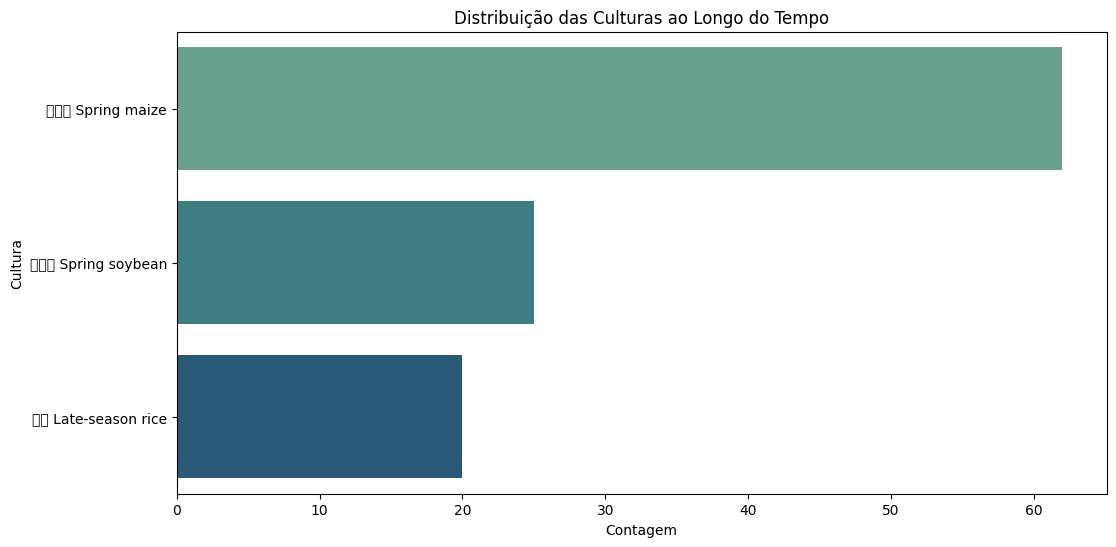

In [6]:
#Distribuição e Frequência das Culturas
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='CurrentCrop', order=df['CurrentCrop'].value_counts().index, palette='crest')
plt.title('Distribuição das Culturas ao Longo do Tempo')
plt.xlabel('Contagem')
plt.ylabel('Cultura')
plt.show()

O sistema de rotação de culturas "milho → milho → soja" é a prática agrícola dominante e mais consistente ao longo do tempo. O  milho também é bastante popular, mas sua contagem varia mais ao longo dos anos. A rotação de apenas arroz é a menos frequente, mas sua consistência mostra que é uma prática bem estabelecida.
A popularidade e a estabilidade da rotação milho → milho → soja sugerem que essa prática contribui para a sustentabilidade da agricultura na Planície Inferior de Liaohe. A rotação com a soja, uma leguminosa, ajuda a fixar o nitrogênio no solo, o que beneficia as colheitas subsequentes de milho e reduz a necessidade de fertilizantes. Isso é uma descoberta-chave para a otimização da produção agrícola e a segurança alimentar na região.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\3249712902.py:9: UserWarning: Glyph 26097 (\N{CJK UNIFIED IDEOGRAPH-65F1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\3249712902.py:9: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\3249712902.py:9: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\3249712902.py:9: UserWarning: Glyph 30000 (\N{CJK UNIFIED IDEOGRAPH-7530}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\3249712902.py:9: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\3249712902.py:9: UserWarning: Glyph 29577 (\

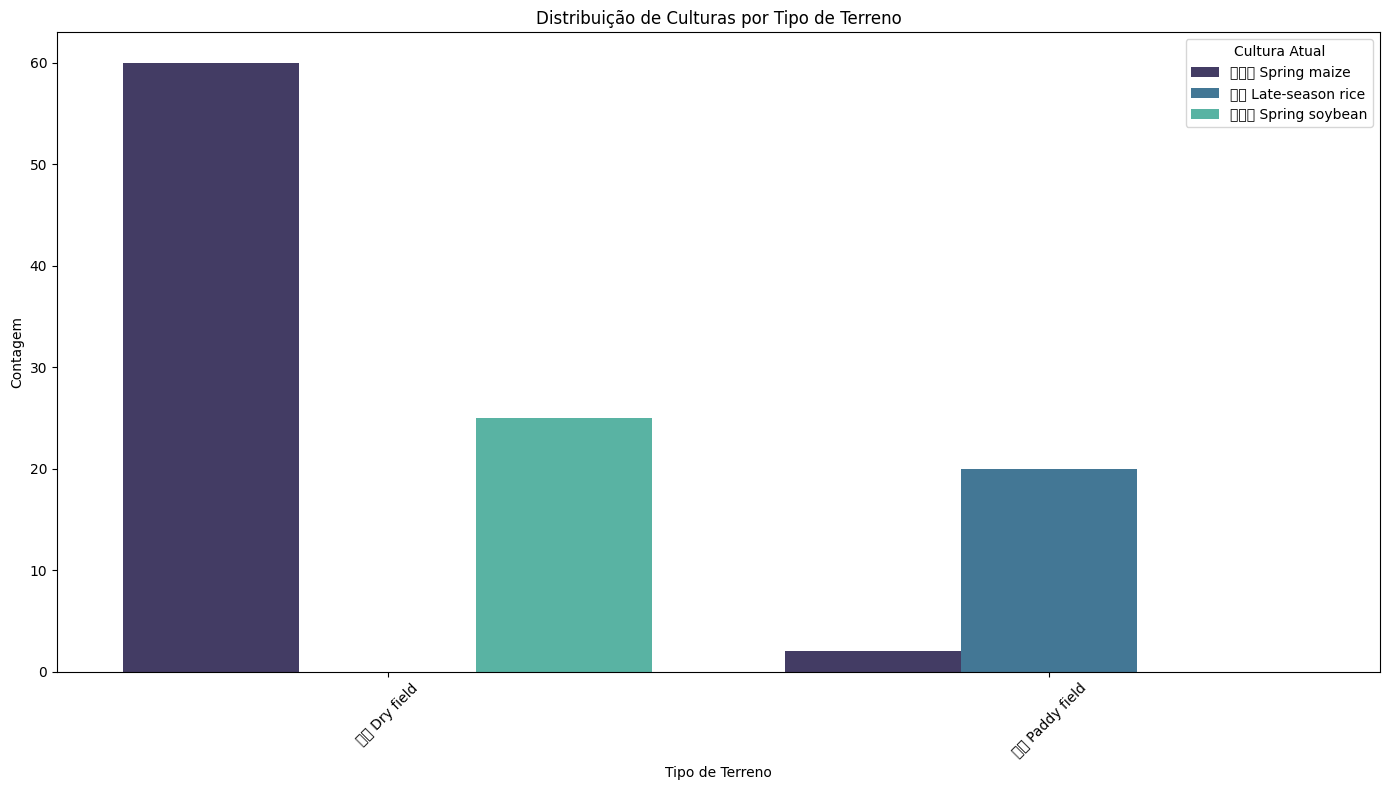

In [7]:
#Tipos de Terreno por Cultura
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='FarmlandType', hue='CurrentCrop', palette='mako')
plt.title('Distribuição de Culturas por Tipo de Terreno')
plt.xlabel('Tipo de Terreno')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.legend(title='Cultura Atual')
plt.tight_layout()
plt.show()

O Milho de Primavera (Spring maize) e o Arroz de Estação Tardia (Late-season rice) são cultivados em tipos de terreno muito específicos, o que demonstra uma prática de otimização no uso da terra.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\152465345.py:10: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\152465345.py:10: UserWarning: Glyph 31291 (\N{CJK UNIFIED IDEOGRAPH-7A3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\152465345.py:10: UserWarning: Glyph 29577 (\N{CJK UNIFIED IDEOGRAPH-7389}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\152465345.py:10: UserWarning: Glyph 31859 (\N{CJK UNIFIED IDEOGRAPH-7C73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\152465345.py:10: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuário\AppData\Local\Temp\ipykernel_1120\152465345.py:10: UserWarning: Glyph 35910 (\

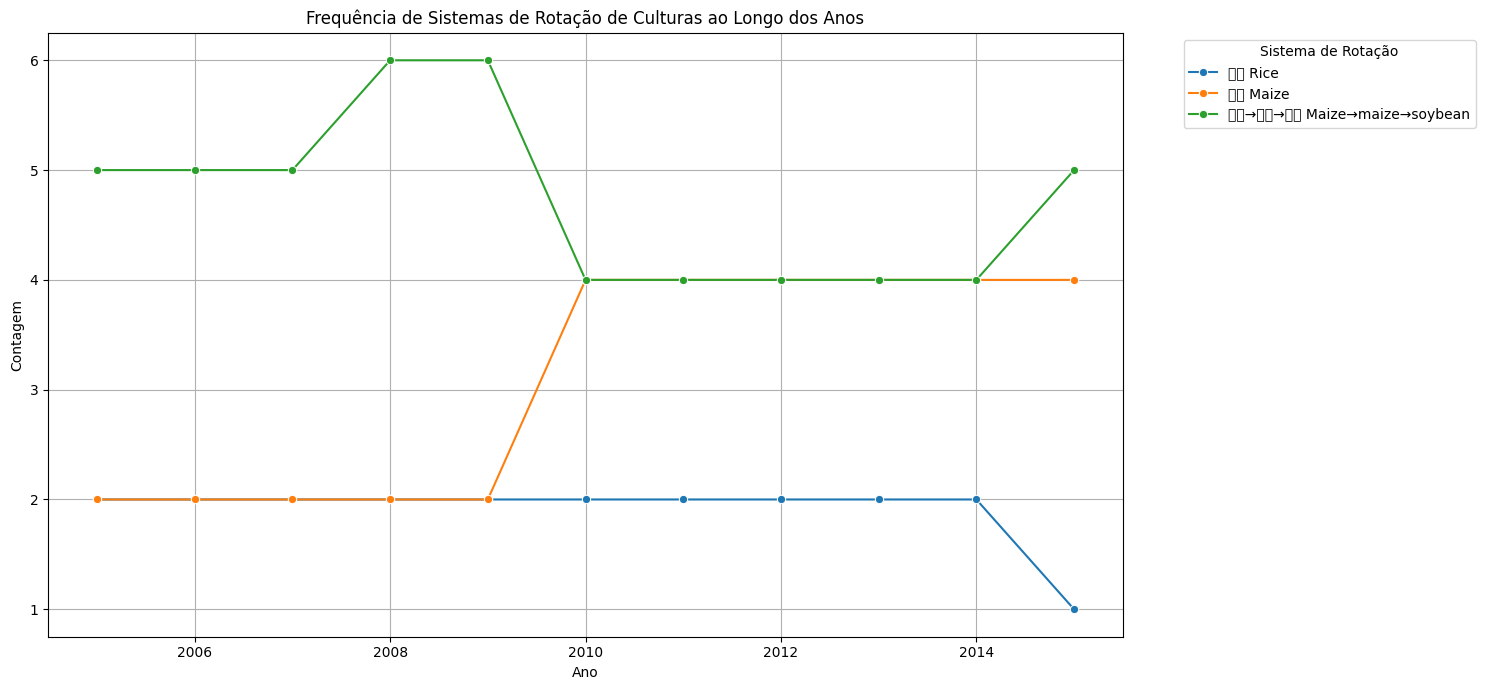

In [8]:
#Rotação de Culturas ao Longo dos Anos
plt.figure(figsize=(15, 7))
df_rotation_counts = df.groupby(['Year', 'CropRotationSystem']).size().reset_index(name='Count')
sns.lineplot(data=df_rotation_counts, x='Year', y='Count', hue='CropRotationSystem', marker='o')
plt.title('Frequência de Sistemas de Rotação de Culturas ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Contagem')
plt.grid(True)
plt.legend(title='Sistema de Rotação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

O Milho de Primavera (Spring maize) é a cultura mais cultivada na Planície Inferior de Liaohe.

In [9]:
#Contar a frequência de cada cultura
culture_counts = df['CurrentCrop'].value_counts()

#Encontrar a cultura mais comum
most_common_culture = culture_counts.idxmax()
most_common_count = culture_counts.max()

print("Culturas-Chave")
print(f"A cultura mais comum no conjunto de dados é: {most_common_culture}")
print(f"Ela aparece {most_common_count} vezes, indicando que é uma cultura principal na região.\n")

print("Frequência de todas as culturas:")
print(culture_counts)

Culturas-Chave
A cultura mais comum no conjunto de dados é: 春玉米 Spring maize
Ela aparece 62 vezes, indicando que é uma cultura principal na região.

Frequência de todas as culturas:
CurrentCrop
春玉米 Spring maize       62
春大豆 Spring soybean     25
晚稻 Late-season rice    20
Name: count, dtype: int64


In [10]:
#Contar a frequência de cada sistema de rotação
rotation_counts = df['CropRotationSystem'].value_counts()

#Encontrar os sistemas de rotação mais comuns 
top_3_rotations = rotation_counts.head(3)

print("Sistemas de Rotação Recomendados")
print("Os sistemas de rotação mais frequentes, que provavelmente indicam uma prática eficaz, são:")
print(top_3_rotations)

Sistemas de Rotação Recomendados
Os sistemas de rotação mais frequentes, que provavelmente indicam uma prática eficaz, são:
CropRotationSystem
玉米→玉米→大豆 Maize→maize→soybean    52
玉米 Maize                        34
水稻 Rice                         21
Name: count, dtype: int64


In [11]:
#Terreno e cultura, e contar a frequência
farmland_culture_distribution = df.groupby(['FarmlandType', 'CurrentCrop']).size().unstack(fill_value=0)

print("Otimização do Uso do Solo")
print("Distribuição de culturas por tipo de terreno:")
print(farmland_culture_distribution)

if '旱地 Dry field' in farmland_culture_distribution.index:
    dry_field_distribution = farmland_culture_distribution.loc['旱地 Dry field']
    most_common_in_dry_field = dry_field_distribution.idxmax()
    print(f"Recomendação: Para otimizar o plantio em '旱地 Dry field' (campo seco), "
          f"a cultura mais indicada é {most_common_in_dry_field}.")

Otimização do Uso do Solo
Distribuição de culturas por tipo de terreno:
CurrentCrop     春大豆 Spring soybean  春玉米 Spring maize  晚稻 Late-season rice
FarmlandType                                                             
旱地 Dry field                    25                60                    0
水田 Paddy field                   0                 2                   20
Recomendação: Para otimizar o plantio em '旱地 Dry field' (campo seco), a cultura mais indicada é 春玉米 Spring maize.


# Conclusão

**Milho de Primavera como Cultura-Chave:** O Milho de Primavera é, de longe, a cultura mais prevalente na área, indicando sua importância fundamental para a produção agrícola e a segurança alimentar regional.

**Otimização do Uso do Solo:** Os agricultores da região já praticam uma alocação eficiente de culturas, plantando milho e soja em campos secos e arroz em campos de arroz. Essa especialização por tipo de terreno demonstra uma adaptação inteligente e otimizada ao ecossistema local.

**Sistemas de Rotação Eficazes:** O sistema de rotação "milho → milho → soja" é o mais popular, sugerindo que é uma prática eficaz para manter a saúde do solo e a produtividade a longo prazo.

Incentivar a adoção dos sistemas de rotação de culturas mais comuns pode ajudar a garantir uma produção estável e sustentável. Além disso, a especialização por tipo de terreno é uma prática a ser mantida e aprimorada, talvez com a introdução de novas variedades de sementes ou tecnologias de manejo que se adequem ainda mais a essas condições específicas.

# **Nathália Sorg**